In [65]:
import matplotlib.pyplot as plt

from src.scp_core import SCP
from experiments.targets import Banana_t, skewt, skewCauchy, CauchyDifference, funnel_t

In [ ]:
# set up target
d = 5
df = 2
# target = CauchyDifference(d, lbd=2)
# target = skewt(a=jnp.linspace(1, 2, d), b=jnp.linspace(2, 1, d))
# target = funnel_t(d, df=df)
# target = skewCauchy(jnp.linspace(-0.9, 0.9, d))
target = Banana_t(d, df)

In [55]:
scp_model = SCP(d, latitude=1.95) # set up SCP class
opt_params, losses = scp_model.minimize_reverse_kl(target.log_prob, ntrain=2000, learning_rate=0.01) # optimize parameters

Running for 1,000 iterations: 100%|██████████| 1000/1000 [00:00<00:00, 7340.77it/s]


Text(0.5, 1.0, 'KL divergence vs training steps')

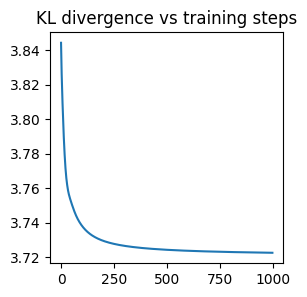

In [57]:
plt.figure(figsize=(3, 3))
plt.plot(losses)
plt.title('KL divergence vs training steps')

In [61]:
# run MCMC
samples, accept_prob = scp_model.rwm_bright_side(target.log_prob, opt_params, seed=1, stepsize=.1, nsample=500_000)
print('Acceptance rate:', accept_prob)

Acceptance rate: 0.852548


(-15.0, 100.0)

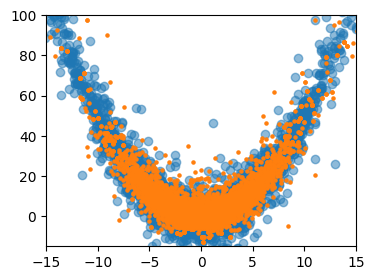

In [62]:
exact_samples = target.sample(seed=1, n=50000)
plt.figure(figsize=(4, 3))
plt.scatter(exact_samples[:, 0], exact_samples[:, 1], alpha=0.5)
plt.scatter(samples[::10, 0], samples[::10, 1], s=5)
plt.xlim(-15, 15)
plt.ylim(-15, 100)

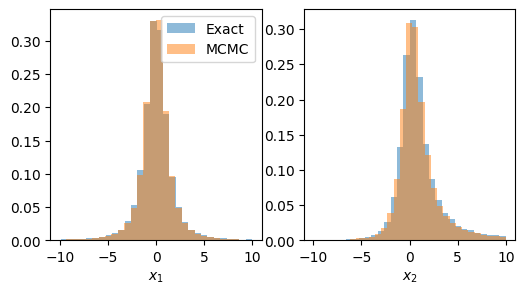

In [64]:
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
for i in [0, 1]:
    ax[i].hist(exact_samples[abs(exact_samples[:, i]) < 10, i], bins=30, density=True, alpha=0.5, label='Exact')
    ax[i].hist(samples[abs(samples[:, i]) < 10, i], bins=30, density=True, alpha=0.5, label='MCMC')
    ax[i].set_xlabel(f'$x_{i+1}$')
ax[0].legend()